100%|█████████████████████████████████████████████████████████████| 792M/792M [00:58<00:00, 13.6MB/s]
100%|███████████████████████████████████████████████████████████| 19.2M/19.2M [00:02<00:00, 7.79MB/s]



>>> Начинаем обучение: U-Net Scratch


Epoch 1: 100%|█████████████████████████████████████████████████████| 230/230 [02:59<00:00,  1.28it/s]


mIoU: 0.3805


Epoch 2: 100%|█████████████████████████████████████████████████████| 230/230 [00:50<00:00,  4.60it/s]


...

mIoU: 0.8086


Epoch 9: 100%|█████████████████████████████████████████████████████| 230/230 [01:51<00:00,  2.06it/s]


mIoU: 0.8234


Epoch 10: 100%|████████████████████████████████████████████████████| 230/230 [01:59<00:00,  1.92it/s]


mIoU: 0.8422


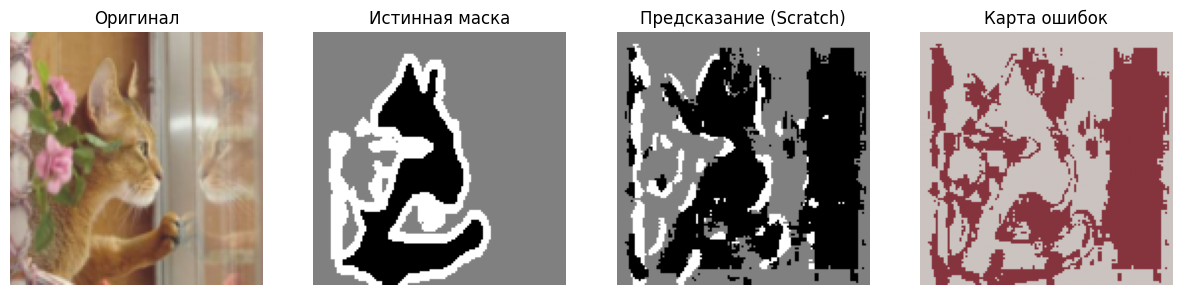

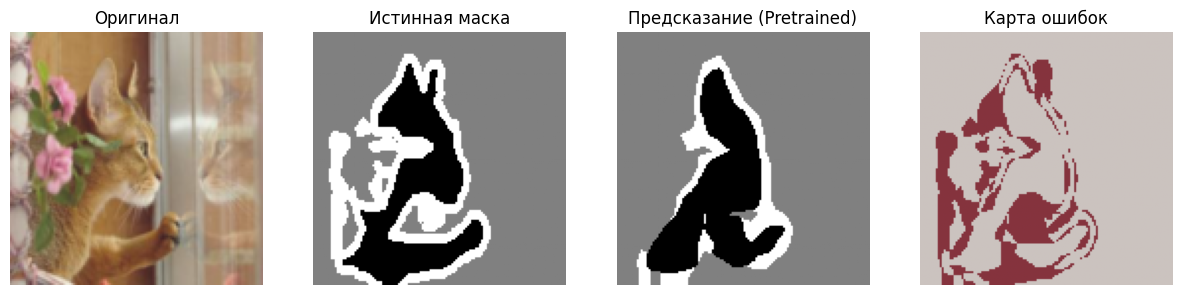


СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК:
     Класс  IoU (U-Net с нуля)  IoU (Pretrained)
0  Питомец            0.574877          0.916545
1      Фон            0.744563          0.961087
2  Граница            0.289977          0.648825


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pandas as pd

# =================================================================
# 1. НАСТРОЙКИ
# =================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 10  # Оптимально для демонстрации сходимости
LR = 1e-4

# Трансформации для изображений и масок (3 класса: Животное, Фон, Контур)
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def target_trans(x):
    x = np.array(x) - 1 # Классы в 0, 1, 2
    x = torch.from_numpy(x).long()
    return T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.NEAREST)(x.unsqueeze(0)).squeeze()

# Загрузка данных
train_ds = OxfordIIITPet(root='./data', split='trainval', target_types='segmentation', download=True, transform=transform, target_transform=target_trans)
test_ds = OxfordIIITPet(root='./data', split='test', target_types='segmentation', download=True, transform=transform, target_transform=target_trans)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =================================================================
# 2. АРХИТЕКТУРЫ МОДЕЛЕЙ (ЧАСТЬ А)
# =================================================================

# Модель 1: U-Net с нуля (Encoder-Decoder + Skip Connections)
class UNetScratch(nn.Module):
    def __init__(self, n_class=3):
        super().__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)
            )
        self.e1 = conv_block(3, 64)
        self.e2 = conv_block(64, 128)
        self.pool = nn.MaxPool2d(2)
        self.up = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.d1 = conv_block(128, 64) # 128 = 64 (up) + 64 (skip)
        self.final = nn.Conv2d(64, n_class, 1)

    def forward(self, x):
        c1 = self.e1(x)
        c2 = self.e2(self.pool(c1))
        x = self.up(c2)
        x = torch.cat([x, c1], dim=1) # SKIP CONNECTION
        return self.final(self.d1(x))

# Модель 2: U-Net + Pretrained Encoder (Transfer Learning)
# Используем DeepLabV3 с ResNet50 (стандарт torchvision для сегментации)
from torchvision.models.segmentation import deeplabv3_resnet50
def get_pretrained_model():
    model = deeplabv3_resnet50(pretrained=True)
    model.classifier[4] = nn.Conv2d(256, 3, kernel_size=1) # Под 3 класса
    return model.to(device)

# =================================================================
# 3. МЕТРИКИ И ОБУЧЕНИЕ (ЧАСТЬ B)
# =================================================================

def calculate_iou(preds, labels, n_class=3):
    preds = torch.argmax(preds, dim=1)
    ious = []
    for cls in range(n_class):
        intersection = ((preds == cls) & (labels == cls)).sum().item()
        union = ((preds == cls) | (labels == cls)).sum().item()
        ious.append(intersection / (union + 1e-6))
    return ious

def train_engine(model, name):
    print(f"\n>>> Начинаем обучение: {name}")
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    history = []

    for epoch in range(EPOCHS):
        model.train()
        epoch_ious = []
        for img, mask in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            img, mask = img.to(device), mask.to(device)
            optimizer.zero_grad()
            out = model(img)
            output = out['out'] if isinstance(out, dict) else out
            loss = criterion(output, mask)
            loss.backward()
            optimizer.step()
            epoch_ious.append(calculate_iou(output, mask))
        
        avg_iou = np.mean(epoch_ious, axis=0)
        print(f"mIoU: {np.mean(avg_iou):.4f}")
        history = avg_iou # сохраняем IoU последнего шага
    return model, history

# Запуск экспериментов
model_1, ious_1 = train_engine(UNetScratch().to(device), "U-Net Scratch")
model_2, ious_2 = train_engine(get_pretrained_model(), "Pretrained DeepLab")

# =================================================================
# 4. АНАЛИЗ ОШИБОК И ОТЧЕТ (ЧАСТЬ C)
# =================================================================

def show_analysis(model, dataset, title):
    model.eval()
    plt.figure(figsize=(15, 4))
    img, mask = dataset[15] # Пример №15
    with torch.no_grad():
        out = model(img.unsqueeze(0).to(device))
        output = out['out'] if isinstance(out, dict) else out
        pred = torch.argmax(output, dim=1).cpu().squeeze().numpy()
    
    true_m = mask.numpy()
    error_map = (pred != true_m) 

    plots = [img.permute(1,2,0).cpu()*0.2+0.5, true_m, pred, error_map]
    titles = ["Оригинал", "Истинная маска", f"Предсказание {title}", "Карта ошибок"]
    for i, (p, t) in enumerate(zip(plots, titles)):
        plt.subplot(1, 4, i+1)
        plt.imshow(p, cmap='gray' if i>0 else None)
        if i == 3: plt.imshow(p, cmap='Reds', alpha=0.8)
        plt.title(t); plt.axis('off')
    plt.show()

show_analysis(model_1, test_ds, "(Scratch)")
show_analysis(model_2, test_ds, "(Pretrained)")

# Итоговая сравнительная таблица
results = pd.DataFrame({
    "Класс": ["Питомец", "Фон", "Граница"],
    "IoU (U-Net с нуля)": ious_1,
    "IoU (Pretrained)": ious_2
})
print("\nСРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК:")
print(results)